In [ ]:
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')

DRIVE = '/content/drive/My Drive/SarcasmProject'

# Load saved metrics from each phase
with open(f'{DRIVE}/models/hmm_metrics.pkl', 'rb') as f:
    hmm = pickle.load(f)
with open(f'{DRIVE}/models/lstm_metrics.pkl', 'rb') as f:
    lstm = pickle.load(f)
with open(f'{DRIVE}/models/roberta_metrics.pkl', 'rb') as f:
    roberta = pickle.load(f)

print("Loaded metrics for all 3 models")

Mounted at /content/drive
Loaded metrics for all 3 models


In [ ]:
results = pd.DataFrame([hmm, lstm, roberta])
results = results[['model', 'accuracy', 'precision', 'recall', 'f1', 'auc']]
results.columns = ['Model', 'Accuracy', 'Precision', 'Recall', 'F1', 'AUC']

# Format as percentages for display
display_df = results.copy()
for col in ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']:
    display_df[col] = display_df[col].apply(lambda x: f"{x:.4f}")

print("=" * 65)
print("          SARCASM DETECTION — MODEL COMPARISON")
print("=" * 65)
print(display_df.to_string(index=False))
print("=" * 65)


          SARCASM DETECTION — MODEL COMPARISON
  Model Accuracy Precision Recall     F1    AUC
    HMM   0.5380    0.5598 0.5142 0.5361 0.5533
   LSTM   0.6798    0.7291 0.5798 0.6459 0.7466
RoBERTa   0.7525    0.7660 0.7271 0.7460 0.8312


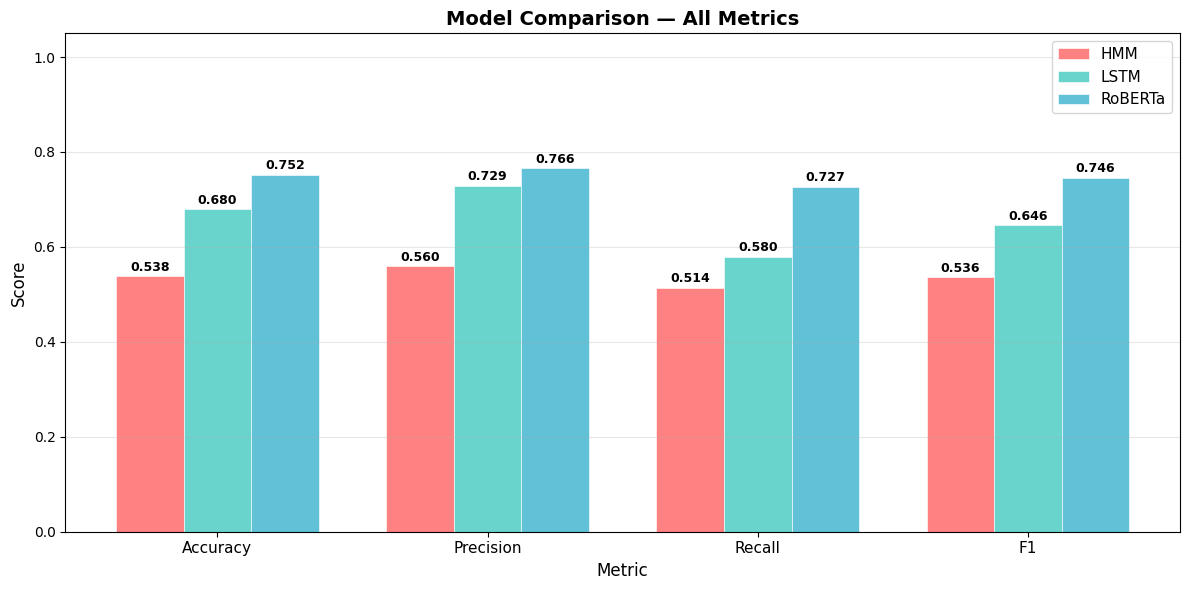

✓ Saved: comparison_bars.png


In [ ]:
models = results['Model'].tolist()
metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

for i, model_name in enumerate(models):
    row = results[results['Model'] == model_name].iloc[0]
    values = [row[m] for m in metrics]
    bars = ax.bar(x + i * width, values, width, label=model_name,
                  color=colors[i], alpha=0.85, edgecolor='white', linewidth=0.5)
    # Add value labels on bars
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xlabel('Metric', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Comparison — All Metrics', fontsize=14, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(metrics, fontsize=11)
ax.legend(fontsize=11)
ax.set_ylim(0, 1.05)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{DRIVE}/outputs/comparison_bars.png', dpi=150)
plt.show()
print("✓ Saved: comparison_bars.png")

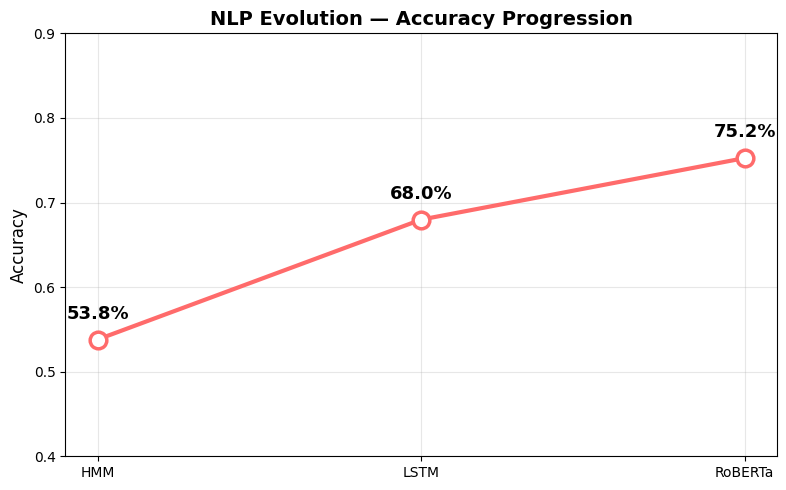

✓ Saved: accuracy_progression.png


In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

accs = results['Accuracy'].tolist()
ax.plot(models, accs, 'o-', color='#FF6B6B', linewidth=3, markersize=12,
        markerfacecolor='white', markeredgewidth=2.5)

for i, (model, acc) in enumerate(zip(models, accs)):
    ax.annotate(f'{acc:.1%}', (i, acc), textcoords="offset points",
                xytext=(0, 15), ha='center', fontsize=13, fontweight='bold')

ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('NLP Evolution — Accuracy Progression', fontsize=14, fontweight='bold')
ax.set_ylim(0.4, 0.9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{DRIVE}/outputs/accuracy_progression.png', dpi=150)
plt.show()
print("✓ Saved: accuracy_progression.png")